{0: 'blog.csdn', 1: 'xiaohongshu.com', 2: 'bilibili.com', 3: 'zhihu.com', 4: 'douban.com', 5: 'ifeng.com', 6: 'v.qq.com', 7: 'jd.com', 8: 'news.cn', 9: 'qq.com', 10: 'souhu.com', 11: 'taobao', 12: 'tieba.baidu.com', 13: 'toutiao.com', 14: 'youku.com', 15: 'vip.com', 16: 'goofish.com'}


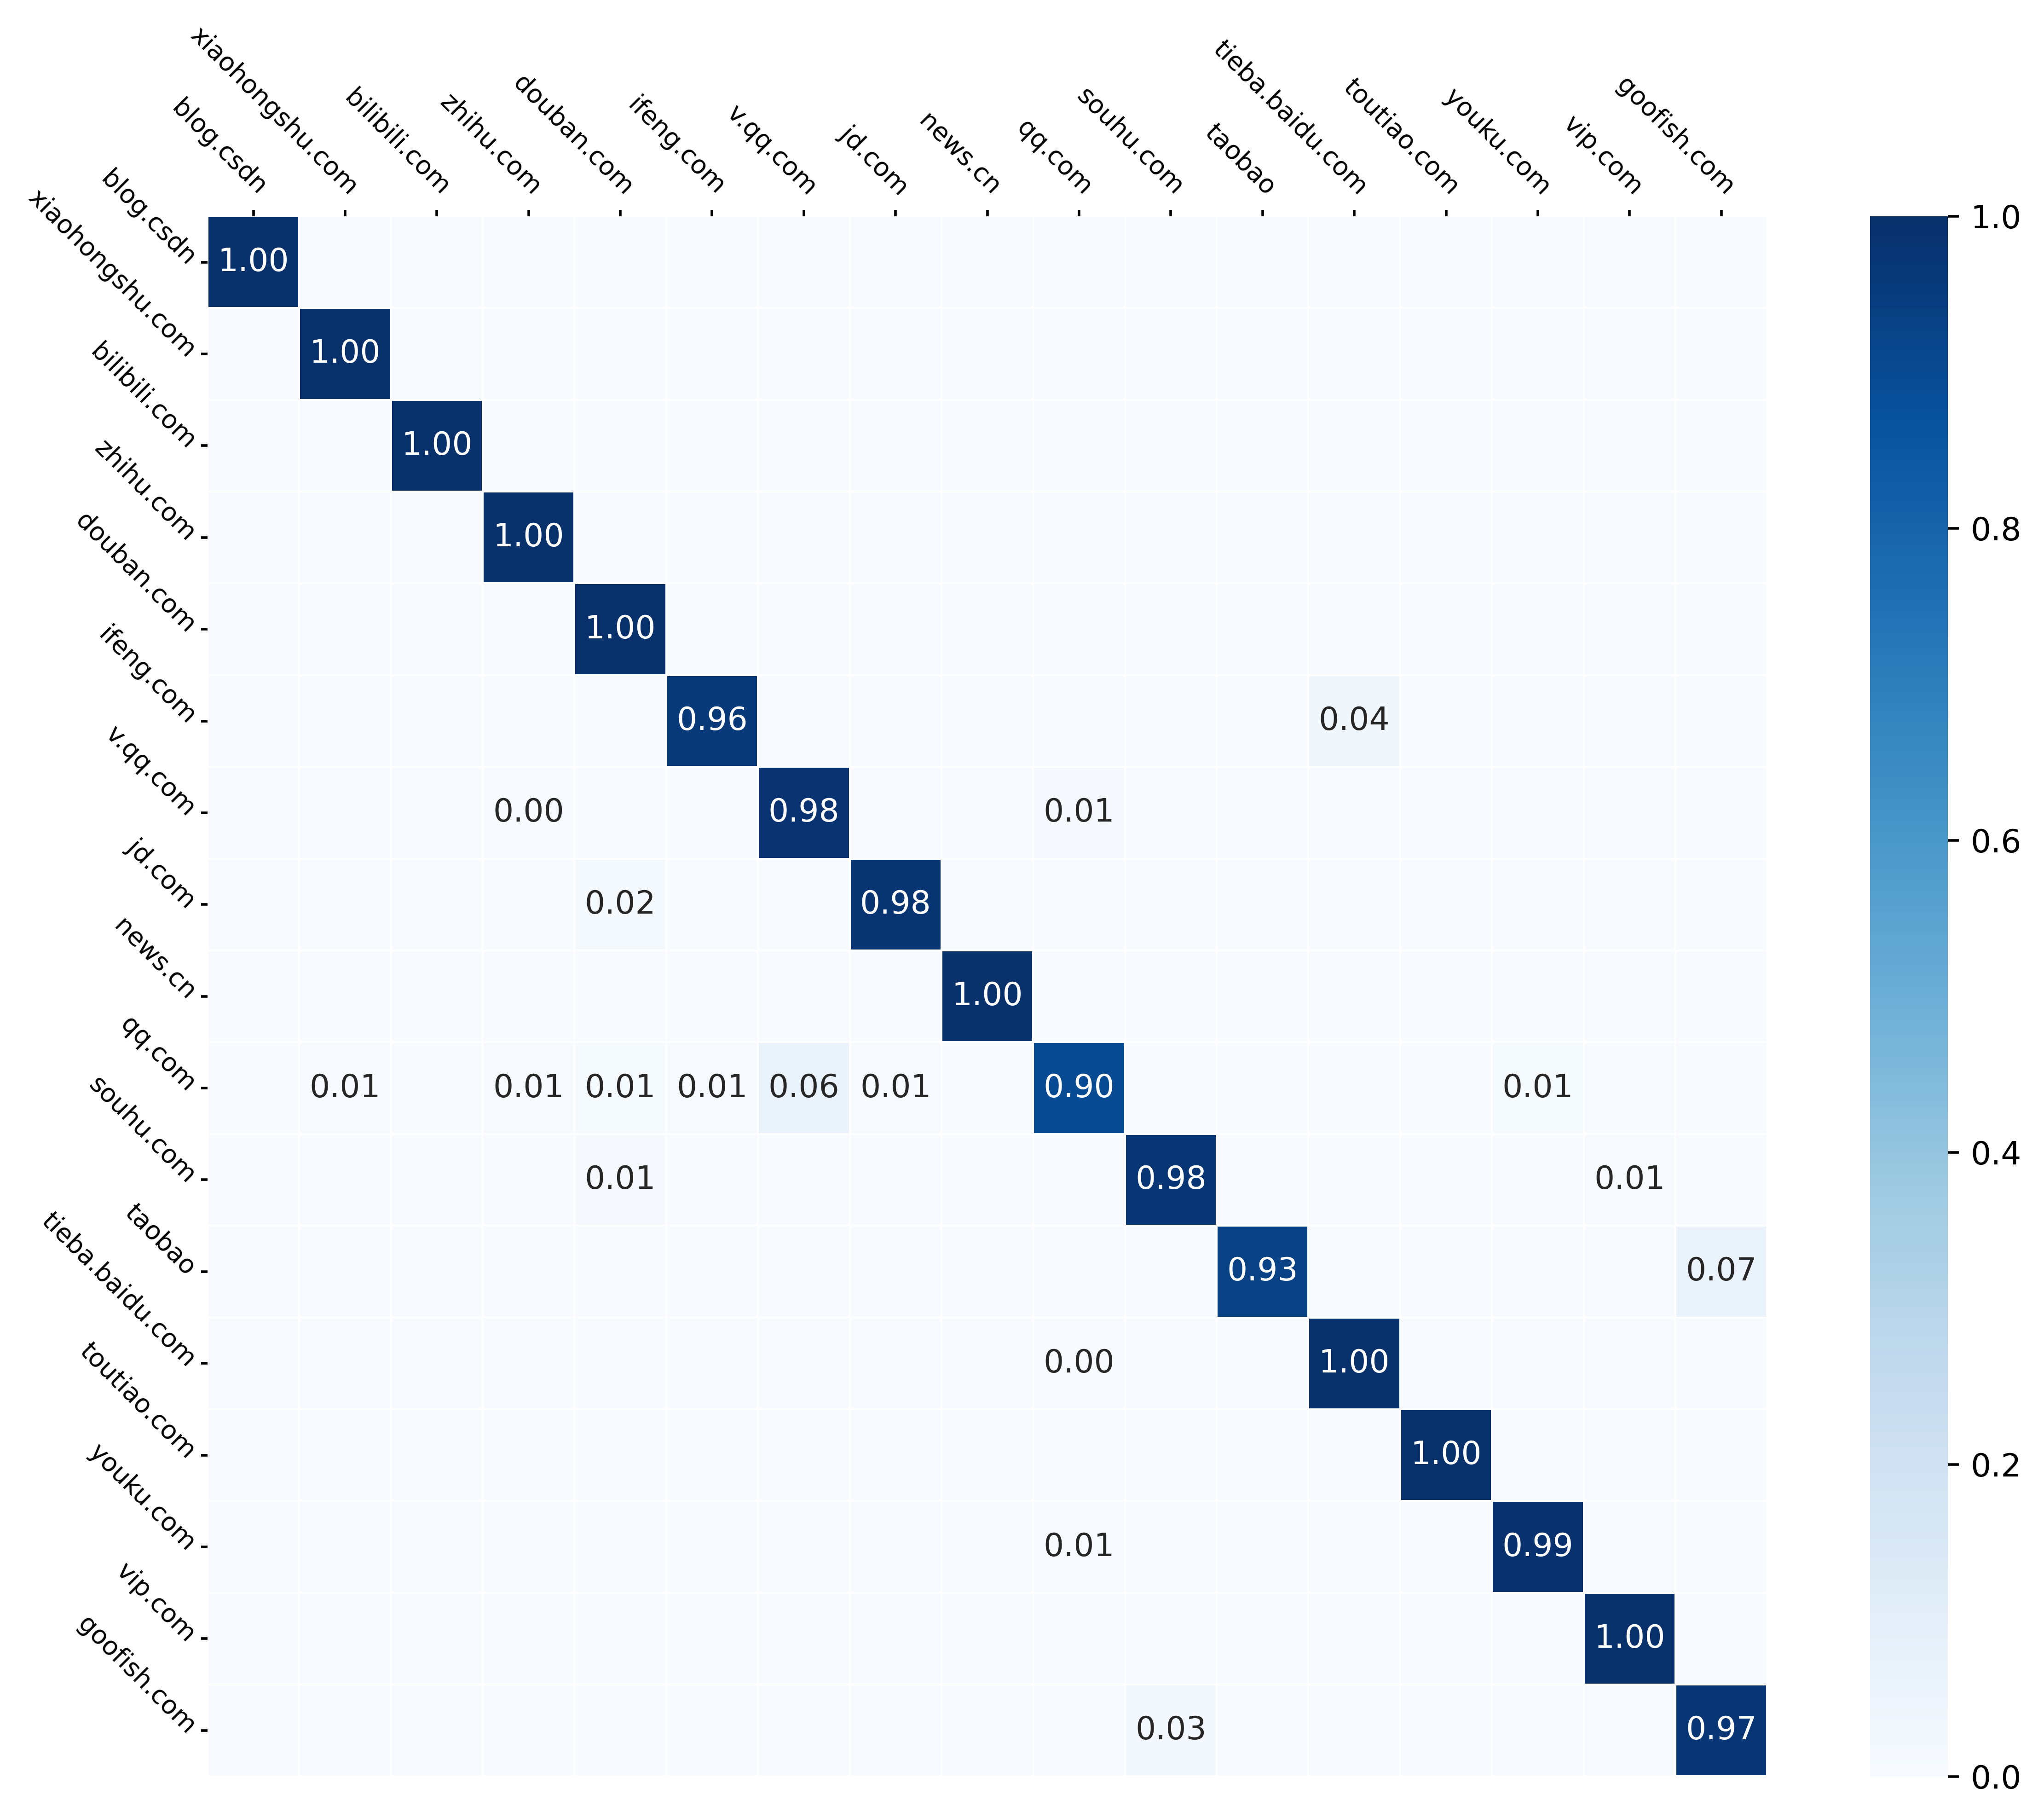

In [ ]:
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import os


# Fig.1 全模块的混淆矩阵
# ===========================
# 已知 y_true / y_pred
# ===========================

# get class name
REMOTE_RAW_DATA_DIR = "/home/tyf/fnnas/Study/Traffic-data/train_raw_data"
dirs = os.listdir(REMOTE_RAW_DATA_DIR)
website_name = {}
website_idx = 0
for dir_name in dirs:
    website_name[website_idx] = dir_name
    website_idx += 1

print(website_name)

root_dir = "/home/tyf/Project/Tantic/raw_feature/stgc_sp_all_class_tls_3/result"
y_true = np.load(f"{root_dir}/fusion_y_true.npy")
y_pred = np.load(f"{root_dir}/fusion_y_pred.npy")
class_names = [website_name[i] for i in range(17)]  # TODO: 按需修改类别名

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# 隐藏 0.00 标注
annot_labels = np.where(cm_norm == 0, "", np.vectorize(lambda x: f"{x:.2f}")(cm_norm))

# 提升清晰度：更高 DPI + 更大字体
plt.figure(figsize=(10, 8), dpi=500)
ax = sns.heatmap(
    cm_norm,
    cmap="Blues",
    annot=annot_labels,
    fmt="",
    cbar=True,
    square=True,
    linewidths=0.3,
    linecolor="white",
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 10},
)

# 把 X 轴标签放到上方
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# 让 X 标签以起点对齐并锚定
ax.set_xticklabels(class_names, rotation=-45, ha="right", rotation_mode="anchor")
ax.set_yticklabels(class_names, rotation=-45, ha="right", rotation_mode="anchor")

# 隐藏刻度线并增加间距
ax.tick_params(axis="both", length=2)
ax.tick_params(axis="x", pad=3, labelsize=8)
ax.tick_params(axis="y", pad=3, labelsize=8)

# ax.set_title("Normalized Confusion Matrix", fontsize=14)

plt.tight_layout()
plt.show()

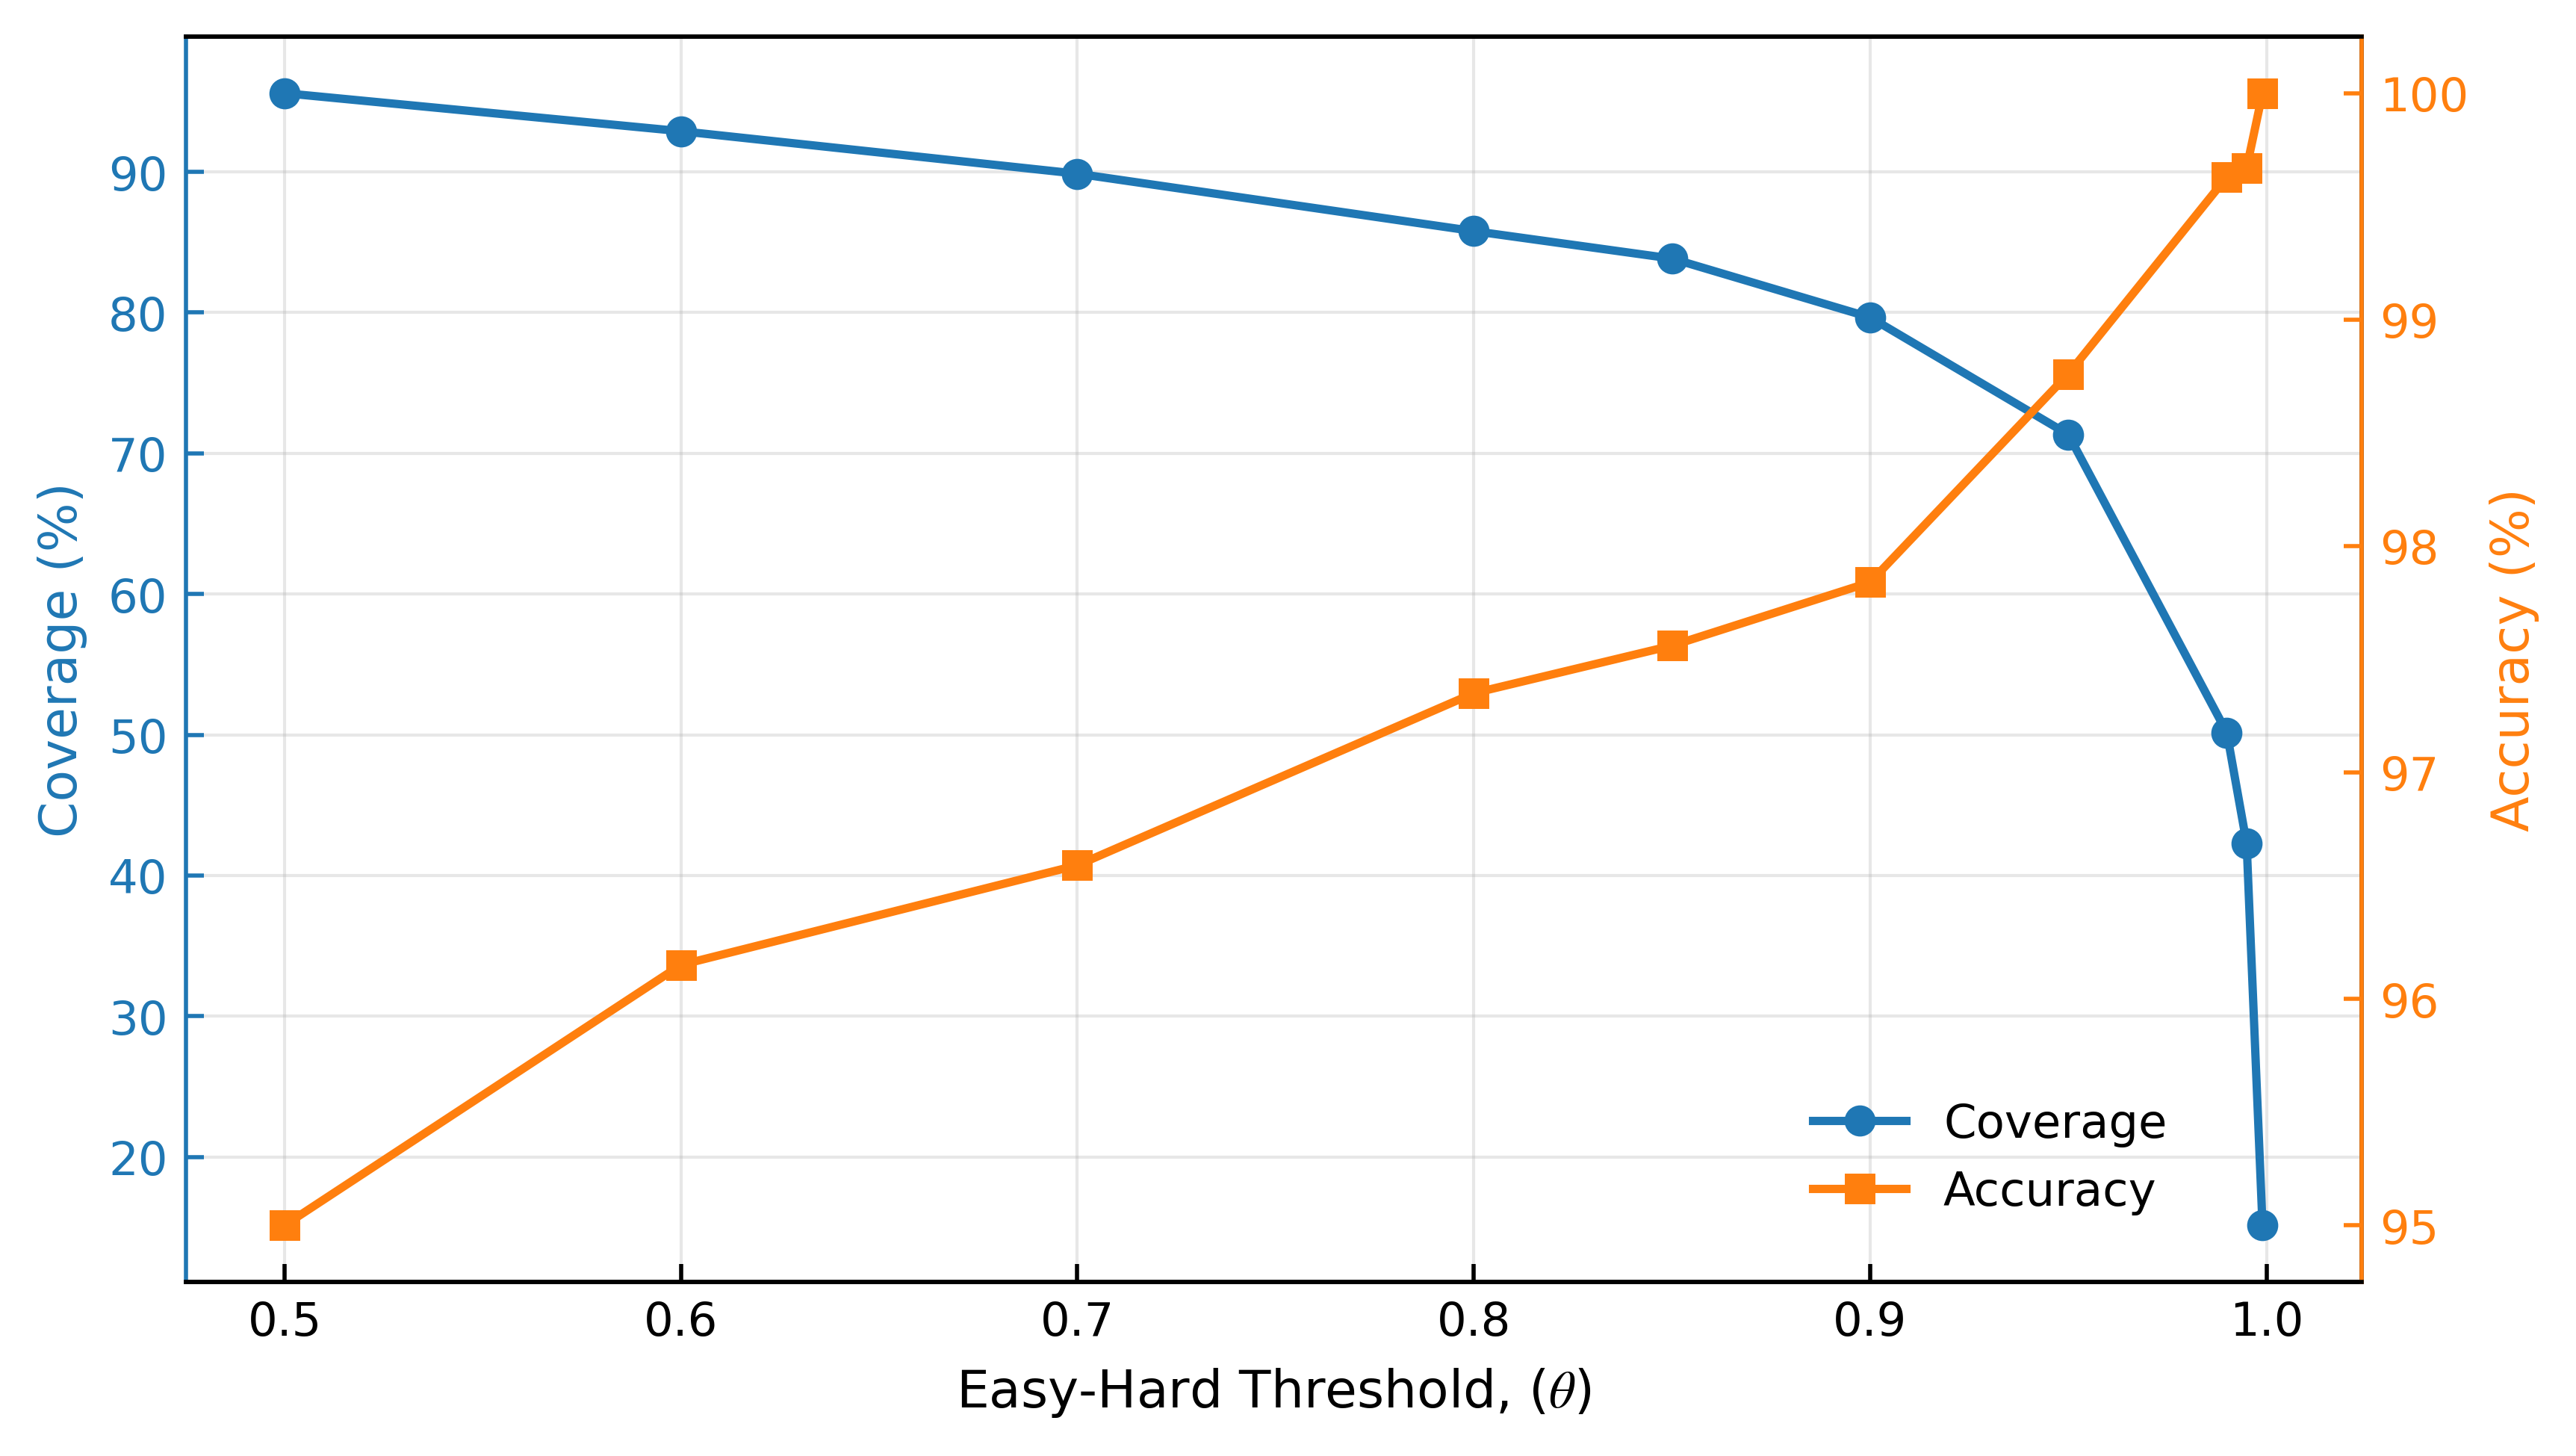

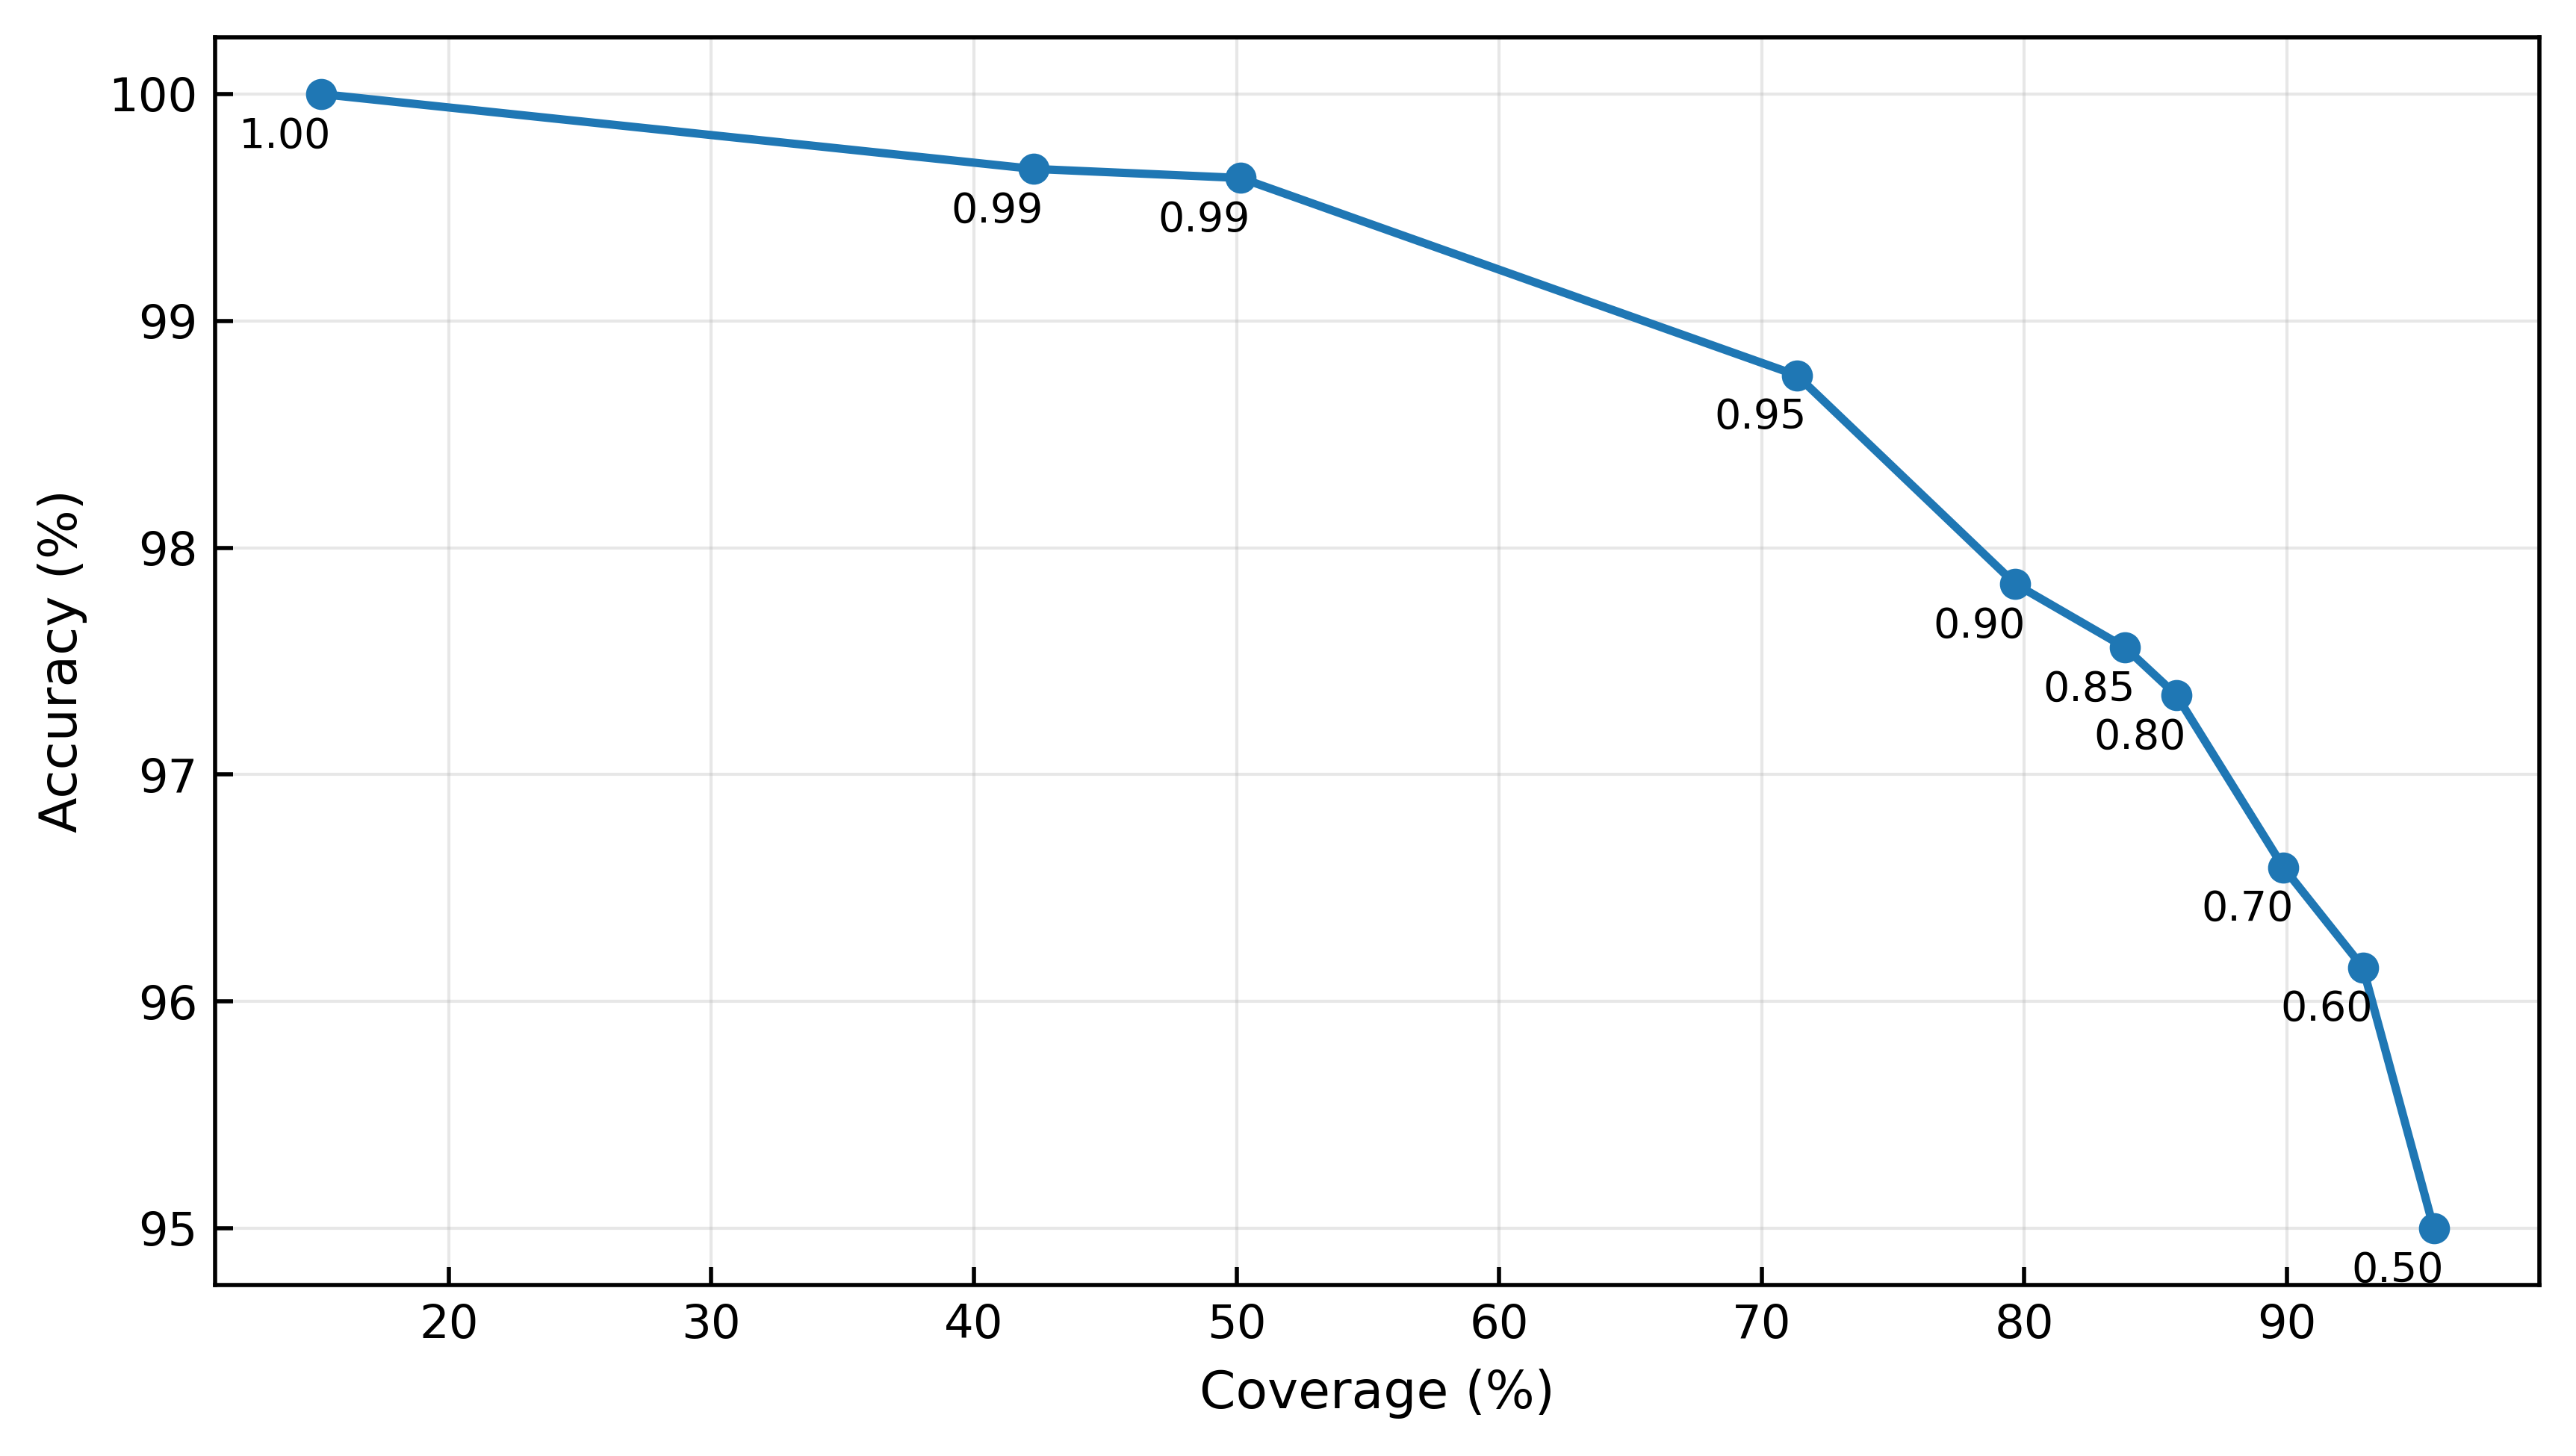

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Fig.2 早期识别模型的阈值与 Cov. 以及 Acc. 的关系

# 这里数据是从 src/models/mfts/analyze_tls_confidence.py 运行结果粘贴而来
# ======================================================================
# TLS Model Performance by Confidence Threshold
# ======================================================================
# Threshold    Coverage     Accuracy     Correct
# ----------------------------------------------------------------------
# 0.500        95.59%       0.9500       1955/2058
# 0.600        92.89%       0.9615       1923/2000
# 0.700        89.87%       0.9659       1869/1935
# 0.800        85.79%       0.9735       1798/1847
# 0.850        83.84%       0.9756       1761/1805
# 0.900        79.66%       0.9784       1678/1715
# 0.950        71.34%       0.9876       1517/1536
# 0.990        50.16%       0.9963       1076/1080
# 0.995        42.27%       0.9967       907/910
# 0.999        15.14%       1.0000       326/326
# ----------------------------------------------------------------------
# ======================================================================
# Low Confidence Samples Analysis
# ======================================================================
# Samples with confidence < 0.99: 1073 (49.84%)
# TLS accuracy on these: 0.8639
# Confidence distribution:
#   Min:    0.2583
#   25%:    0.7592
#   Median: 0.9358
#   75%:    0.9705
#   Max:    0.9900

# ======================================================================
# Conclusion
# ======================================================================
# Overall TLS accuracy: 0.9303
# High confidence (≥0.99) TLS accuracy: 0.9963

# → Two-stage benefits:
#   1. 50.2% samples use fast TLS branch (high accuracy)
#   2. 49.8% samples use fusion (correcting TLS errors)
thresholds = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99, 0.995, 0.999]
coverage = [
    0.9559,
    0.9289,
    0.8987,
    0.8579,
    0.8384,
    0.7966,
    0.7134,
    0.5016,
    0.4227,
    0.1514,
]
accuracy = [0.95, 0.9615, 0.9659, 0.9735, 0.9756, 0.9784, 0.9876, 0.9963, 0.9967, 1.0]

# 论文常用字体与字号（可按期刊要求调整）
plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "mathtext.fontset": "stix",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "lines.linewidth": 1.6,
        "lines.markersize": 5,
        "axes.linewidth": 0.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
    }
)
plt.rcParams["figure.dpi"] = 500  # 屏幕显示
plt.rcParams["savefig.dpi"] = 300  # 保存图片

# y 轴显示为百分数但不加 %
percent_no_sign = FuncFormatter(lambda v, _: f"{v*100:.0f}")

# 1) 双轴图
fig, ax1 = plt.subplots(figsize=(7, 4))
(line1,) = ax1.plot(
    thresholds, coverage, marker="o", color="tab:blue", label="Coverage"
)
ax1.set_xlabel(r"Easy-Hard Threshold, ($\theta$)")
ax1.set_ylabel(r"Coverage (%)", color="tab:blue")
ax1.yaxis.set_major_formatter(percent_no_sign)
ax1.tick_params(axis="y", colors="tab:blue", labelcolor="tab:blue")
ax1.spines["left"].set_color("tab:blue")
ax1.grid(True, alpha=0.3, linewidth=0.6)

ax2 = ax1.twinx()
(line2,) = ax2.plot(
    thresholds, accuracy, marker="s", color="tab:orange", label="Accuracy"
)
ax2.set_ylabel(r"Accuracy (%)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.yaxis.set_major_formatter(percent_no_sign)
ax2.spines["right"].set_color("tab:orange")
ax2.tick_params(axis="y", colors="tab:orange")
ax2.spines["left"].set_visible(False)
ax1.spines["left"].set_color("tab:blue")
ax1.tick_params(axis="y", colors="tab:blue", labelcolor="tab:blue")

ax1.legend(
    handles=[line1, line2],
    loc="lower right",
    bbox_to_anchor=(0.93, 0.02),
    frameon=False,
)

# plt.title("TLS: Threshold vs Coverage & Accuracy")
plt.tight_layout()
plt.show()

# 2) Accuracy vs Coverage
plt.figure(figsize=(7, 4))
plt.plot(coverage, accuracy, marker="o", color="tab:blue")
for x, y, t in zip(coverage, accuracy, thresholds):
    plt.annotate(
        f"{t:.2f}",
        (x, y),
        textcoords="offset points",
        xytext=(-7, -12),
        ha="center",
        va="bottom",
        fontsize=8,
    )
plt.xlabel("Coverage (%)")
plt.ylabel("Accuracy (%)")
# plt.title("TLS: Accuracy vs Coverage")
ax = plt.gca()
ax.xaxis.set_major_formatter(percent_no_sign)
ax.yaxis.set_major_formatter(percent_no_sign)
plt.grid(True, alpha=0.3, linewidth=0.6)
plt.tight_layout()
plt.show()

In [ ]:
#